## 1. IMPORTS


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay, classification_report)

In [3]:
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
sns.set_style('whitegrid')

## 2. LOAD & UNDERSTAND DATA

In [4]:
df = pd.read_csv('diabetes.csv')
print(df.shape)
print(df.dtypes)
print(df.describe().T)
print(df['Outcome'].value_counts(normalize=True) * 100)

num_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI',
            'DiabetesPedigreeFunction','Age']

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Select features
features = ["Glucose", "BMI", "Age", "Insulin"]
# Generate descriptive statistics
stats = df[features].describe().T
# Add skewness
stats["Skew"] = df[features].skew()
# Select required columns
stats = stats[["mean", "std", "min", "max", "Skew"]]
# Rename columns
stats.columns = ["Mean", "Std", "Min", "Max", "Skew"]

# Display
print(stats)

               Mean         Std   Min    Max      Skew
Glucose  120.894531   31.972618   0.0  199.0  0.173754
BMI       31.992578    7.884160   0.0   67.1 -0.428982
Age       33.240885   11.760232  21.0   81.0  1.129597
Insulin   79.799479  115.244002   0.0  846.0  2.272251


## 3. EDA

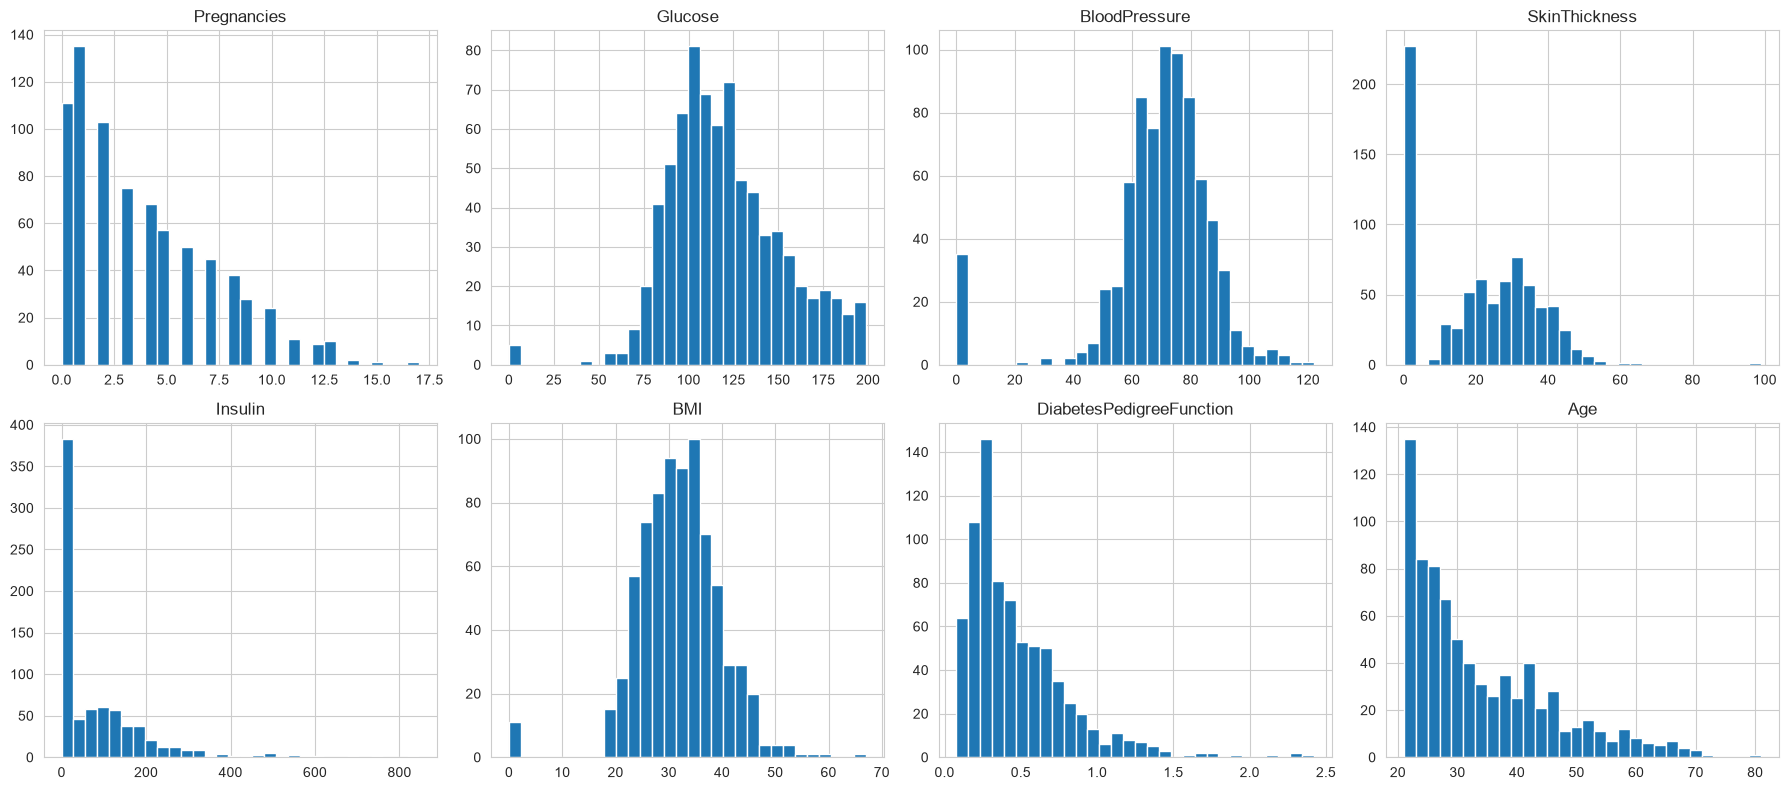

In [8]:
# Univariate
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col)

plt.tight_layout()

# Save the figure
plt.savefig("figure/histograms.png", dpi=300, bbox_inches="tight")

plt.show()

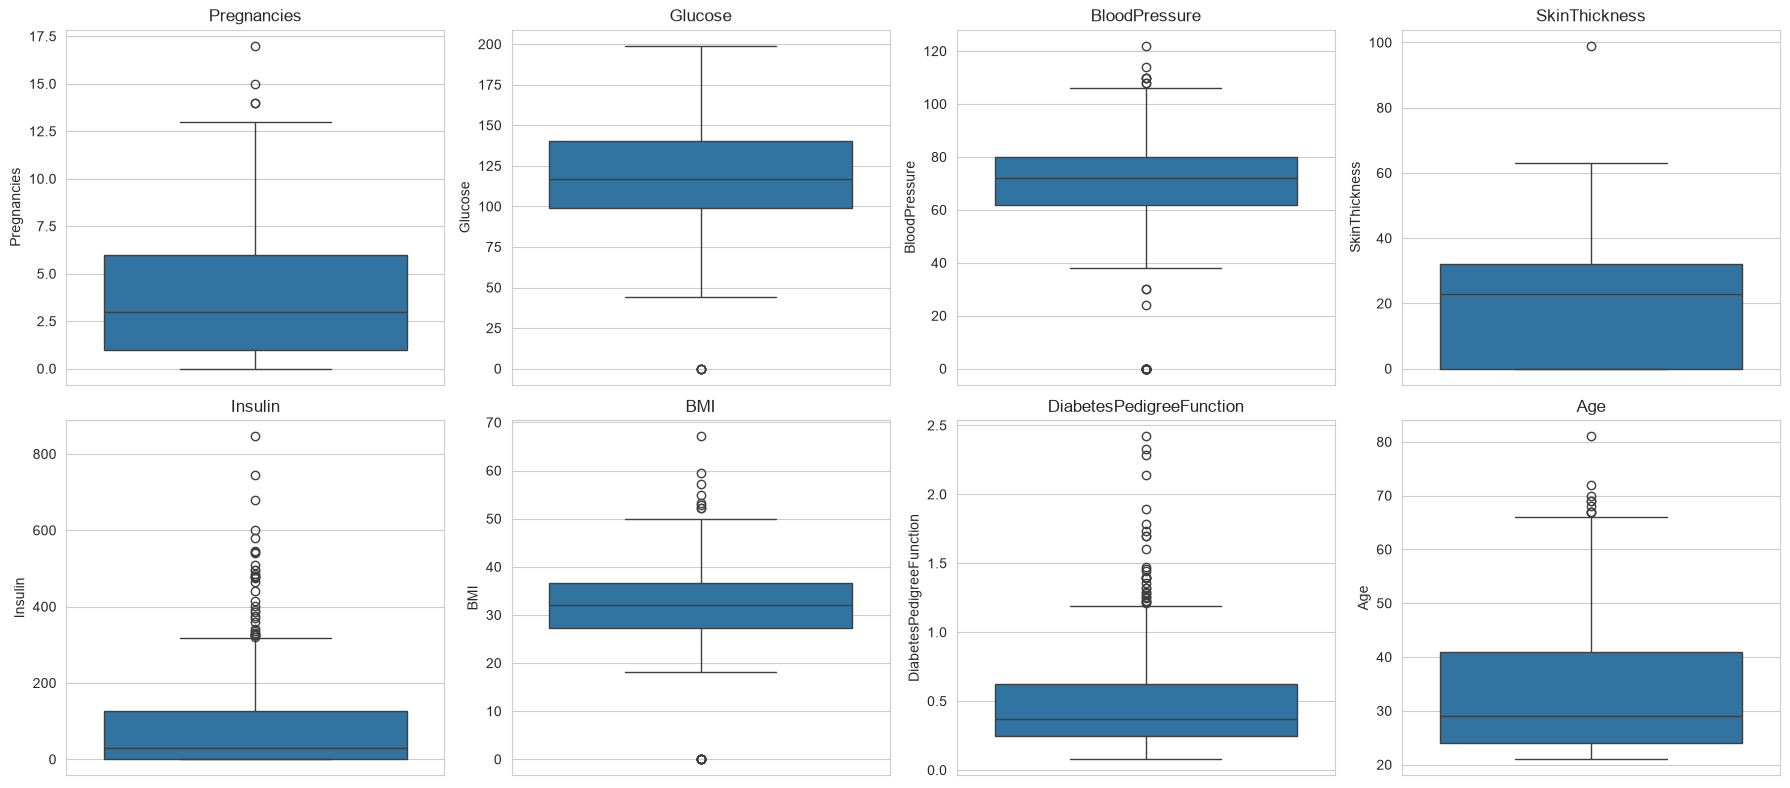

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

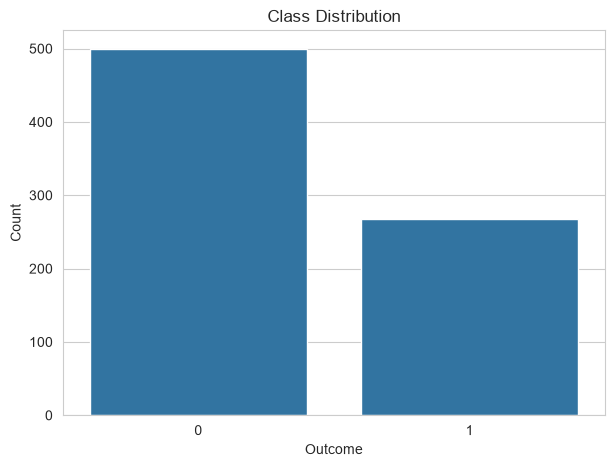

In [10]:
# Target distribution
plt.figure(figsize=(7, 5))

sns.countplot(x='Outcome', data=df)

plt.title('Class Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.savefig(
    "figure/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

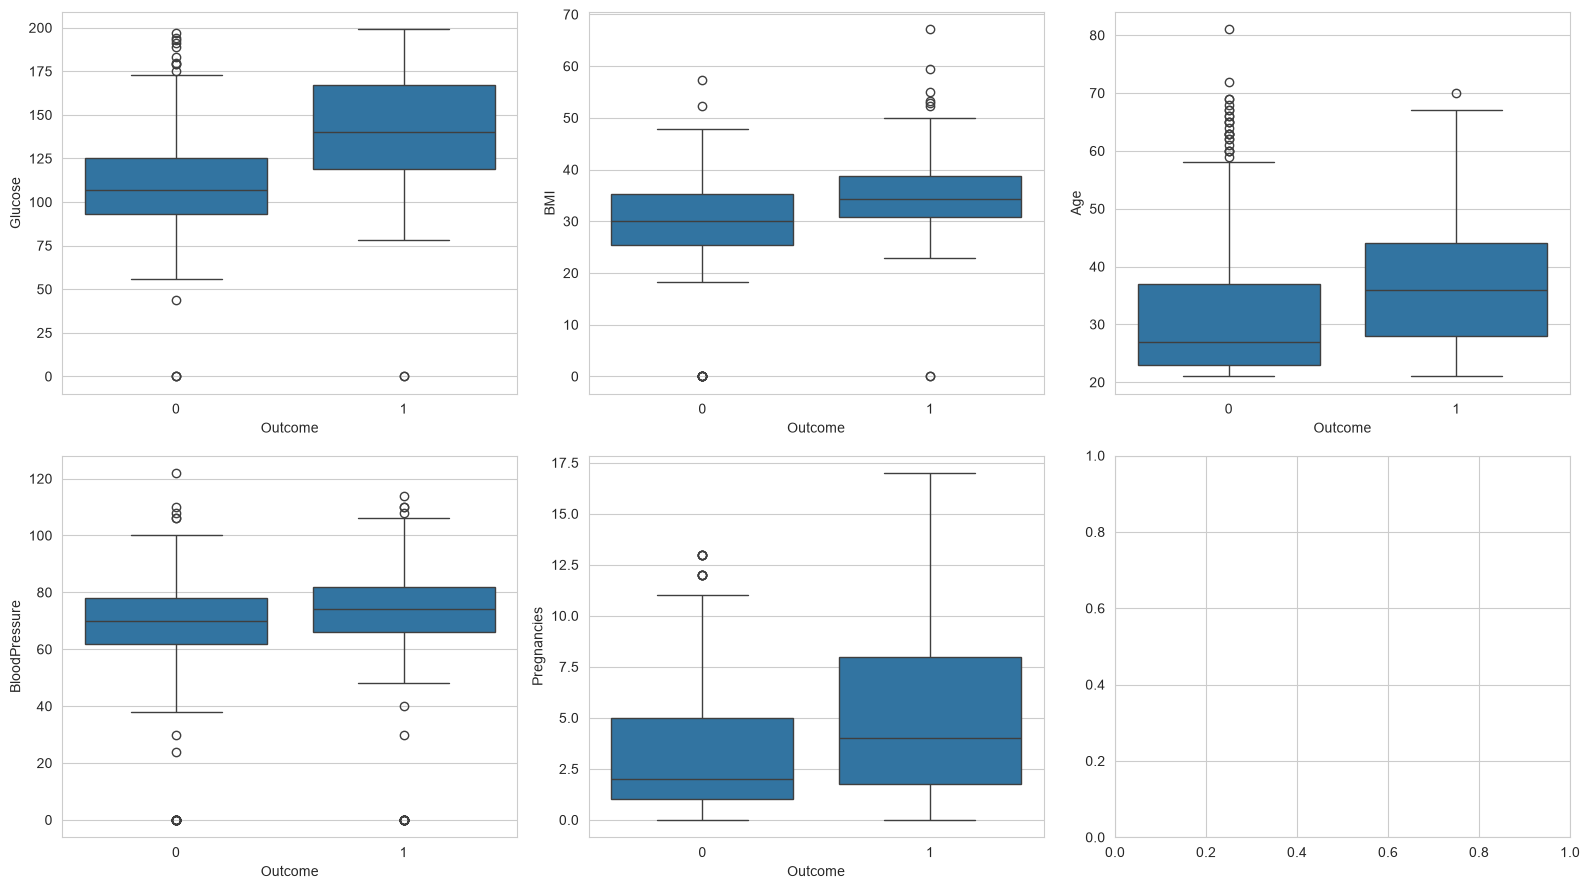

In [11]:
# Bivariate
bivar_cols = ['Glucose','BMI','Age','BloodPressure','Pregnancies']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), bivar_cols):
    sns.boxplot(x='Outcome', y=col, data=df, ax=ax)
plt.tight_layout(); plt.show()

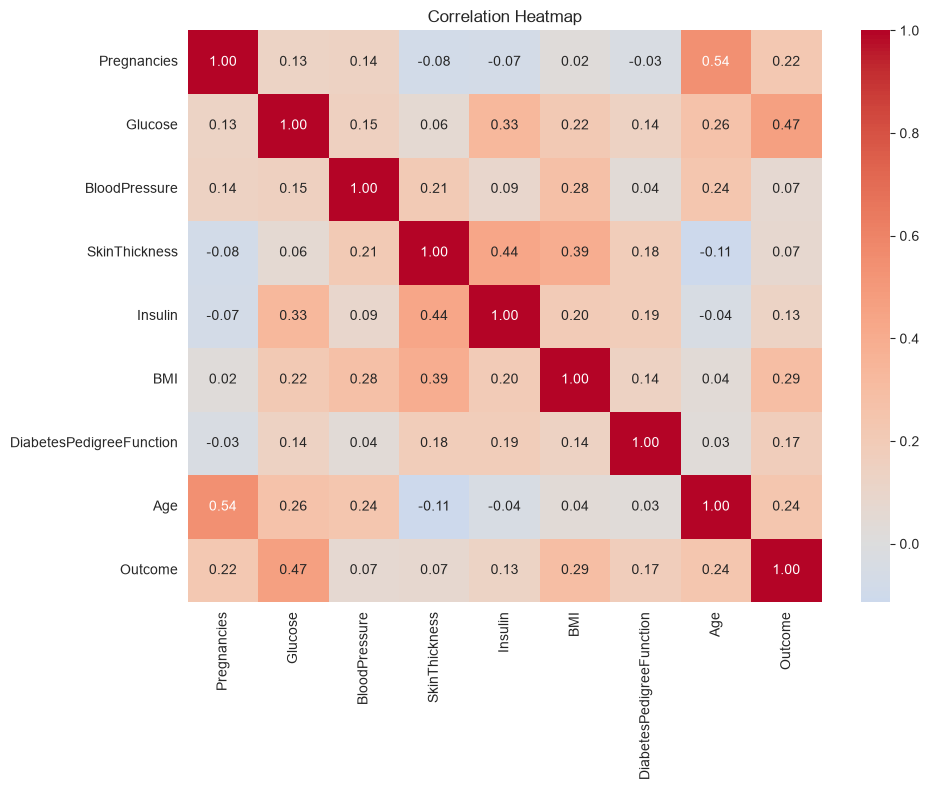

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [12]:
# Correlation
corr = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)

plt.title('Correlation Heatmap')
plt.tight_layout()
# Save image for LaTeX
plt.savefig('figure/correlation_heatmap.png',dpi=300,bbox_inches='tight')

plt.show()

# Print correlations with Outcome
print(
    corr['Outcome']
    .drop('Outcome')
    .sort_values(key=abs, ascending=False)
)

In [13]:
# Outliers (IQR)
def iqr_outliers(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'feature': col, 'n_outliers': n, 'pct': round(100*n/len(data), 2)})
    return pd.DataFrame(rows)
print(iqr_outliers(df, num_cols))

                    feature  n_outliers   pct
0               Pregnancies           4  0.52
1                   Glucose           5  0.65
2             BloodPressure          45  5.86
3             SkinThickness           1  0.13
4                   Insulin          34  4.43
5                       BMI          19  2.47
6  DiabetesPedigreeFunction          29  3.78
7                       Age           9  1.17


## 4. DATA QUALITY: implausible zeros -> NaN -> impute

In [14]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print((df[zero_cols] == 0).sum())          # zeros are physiologically impossible here
print('Duplicates:', df.duplicated().sum())

df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

# Impute with median, stratified by Outcome (fit only on train later to avoid leakage
# — shown here on full df for illustration; see pipeline note below)
for col in zero_cols:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Duplicates: 0


## 5. FEATURE ENGINEERING

In [15]:
fe = df_clean.copy()
fe['AgeGroup'] = pd.cut(fe['Age'], bins=[20,30,40,50,100], labels=['21-30','31-40','41-50','51+'])
fe['BMICategory'] = pd.cut(fe['BMI'], bins=[0,18.5,25,30,100],
                            labels=['Underweight','Normal','Overweight','Obese'])
fe['GlucoseCategory'] = pd.cut(fe['Glucose'], bins=[0,99,125,300],
                                labels=['Normal','Prediabetic','Diabetic_range'])
fe['Glucose_BMI_interaction'] = fe['Glucose'] * fe['BMI']
fe['Insulin_log'] = np.log1p(fe['Insulin'])

fe_encoded = pd.get_dummies(fe, columns=['AgeGroup','BMICategory','GlucoseCategory'], drop_first=True)


## 6. TRAIN/TEST SPLIT + SCALING

In [16]:
X = fe_encoded.drop(columns=['Outcome'])
y = fe_encoded['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 7. BASELINE MODELS

In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_keras=False, threshold=0.5):
    start = time.time()
    if not is_keras:
        model.fit(X_tr, y_tr)
    train_time = time.time() - start

    if is_keras:
        y_prob = model.predict(X_te, verbose=0).ravel()
    elif hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_prob),
        'Train Time (s)': round(train_time, 3)
    }, y_pred, y_prob

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'SVM': SVC(probability=True, kernel='rbf', random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_SEED),
}

results, predictions = [], {}
for name, model in models.items():
    metrics, y_pred, y_prob = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(metrics)
    predictions[name] = (y_pred, y_prob)
    print(name, metrics)

Logistic Regression {'Model': 'Logistic Regression', 'Accuracy': 0.7792207792207793, 'Precision': 0.6785714285714286, 'Recall': 0.7037037037037037, 'F1': 0.6909090909090909, 'ROC-AUC': 0.8533333333333334, 'Train Time (s)': 0.014}
KNN {'Model': 'KNN', 'Accuracy': 0.7922077922077922, 'Precision': 0.6896551724137931, 'Recall': 0.7407407407407407, 'F1': 0.7142857142857143, 'ROC-AUC': 0.8687962962962963, 'Train Time (s)': 0.002}
SVM {'Model': 'SVM', 'Accuracy': 0.8246753246753247, 'Precision': 0.7368421052631579, 'Recall': 0.7777777777777778, 'F1': 0.7567567567567568, 'ROC-AUC': 0.8983333333333333, 'Train Time (s)': 0.03}
Decision Tree {'Model': 'Decision Tree', 'Accuracy': 0.8766233766233766, 'Precision': 0.8571428571428571, 'Recall': 0.7777777777777778, 'F1': 0.8155339805825242, 'ROC-AUC': 0.9017592592592593, 'Train Time (s)': 0.005}
Random Forest {'Model': 'Random Forest', 'Accuracy': 0.8701298701298701, 'Precision': 0.8148148148148148, 'Recall': 0.8148148148148148, 'F1': 0.8148148148148

## 8. MLP

In [64]:
def build_mlp(input_dim, units=(32,16), dropout=0.2, lr=0.001, l2=0.0):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))
    for n_units in units:
        reg = regularizers.l2(l2) if l2 > 0 else None
        model.add(layers.Dense(n_units, activation='relu', kernel_regularizer=reg))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

In [65]:
mlp = build_mlp(X_train_scaled.shape[1], units=(32,16), dropout=0.2, lr=0.001)
mlp.summary()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = mlp.fit(X_train_scaled, y_train, validation_split=0.2, epochs=150,
                   batch_size=32, callbacks=[early_stop], verbose=0)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

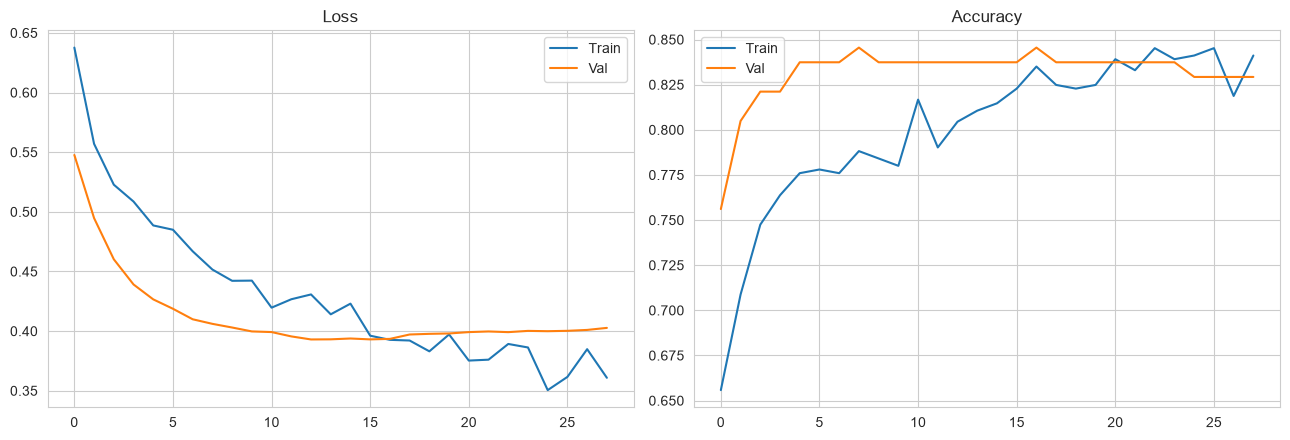

In [66]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train'); axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

mlp_metrics, mlp_pred, mlp_prob = evaluate_model('MLP', mlp, X_train_scaled, y_train, X_test_scaled, y_test, is_keras=True)
results.append(mlp_metrics)
predictions['MLP'] = (mlp_pred, mlp_prob)

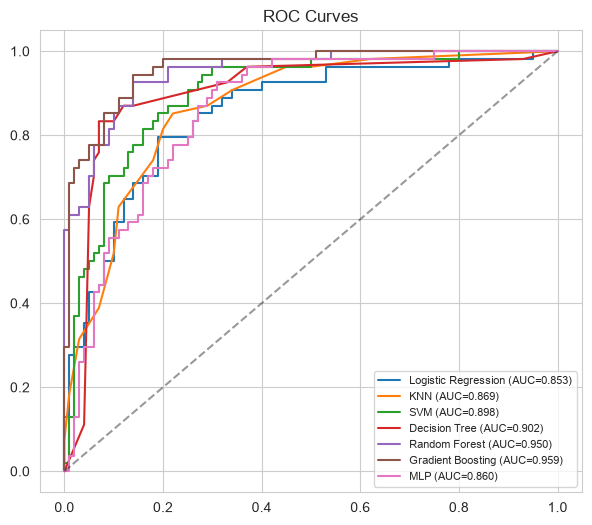

In [67]:
# ROC / PR curves for all models
plt.figure(figsize=(7,6))
for name, (y_pred, y_prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.legend(fontsize=8); plt.title('ROC Curves'); plt.show()

## 9. COMPARISON TABLE

In [68]:
results_df = pd.DataFrame(results).set_index('Model').round(3)
print(results_df.sort_values('F1', ascending=False))

                     Accuracy  Precision  Recall     F1  ROC-AUC  \
Model                                                              
Gradient Boosting       0.877      0.807   0.852  0.829    0.959   
Decision Tree           0.877      0.857   0.778  0.816    0.902   
Random Forest           0.870      0.815   0.815  0.815    0.950   
SVM                     0.825      0.737   0.778  0.757    0.898   
KNN                     0.792      0.690   0.741  0.714    0.869   
MLP                     0.779      0.672   0.722  0.696    0.860   
Logistic Regression     0.779      0.679   0.704  0.691    0.853   

                     Train Time (s)  
Model                                
Gradient Boosting             0.367  
Decision Tree                 0.007  
Random Forest                 0.977  
SVM                           0.081  
KNN                           0.003  
MLP                           0.000  
Logistic Regression           0.023  


## 10. HYPERPARAMETER TUNING (manual grid search)


In [69]:
from itertools import product

param_grid = {
    'units': [(32,16), (64,32), (64,32,16)],
    'lr': [0.001, 0.0005],
    'batch_size': [16, 32],
    'dropout': [0.2, 0.3],
}

X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
)

tuning_results = []
keys, values = zip(*param_grid.items())
for combo in product(*values):
    cfg = dict(zip(keys, combo))
    model = build_mlp(X_tr_sub.shape[1], units=cfg['units'], dropout=cfg['dropout'], lr=cfg['lr'])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_tr_sub, y_tr_sub, validation_data=(X_val_sub, y_val_sub),
              epochs=100, batch_size=cfg['batch_size'], callbacks=[es], verbose=0)
    val_prob = model.predict(X_val_sub, verbose=0).ravel()
    val_auc = roc_auc_score(y_val_sub, val_prob)
    tuning_results.append({**cfg, 'val_auc': val_auc})

tuning_df = pd.DataFrame(tuning_results).sort_values('val_auc', ascending=False)
print(tuning_df.head())
best_cfg = tuning_df.iloc[0]

           units      lr  batch_size  dropout   val_auc
20  (64, 32, 16)  0.0005          16      0.2  0.960174
8       (64, 32)  0.0010          16      0.2  0.960174
16  (64, 32, 16)  0.0010          16      0.2  0.957849
10      (64, 32)  0.0010          32      0.2  0.956686
4       (32, 16)  0.0005          16      0.2  0.955814


## 11. FINAL MODEL: retrain best config on full train set, evaluate on test set


{'Model': 'Final Tuned MLP', 'Accuracy': 0.8116883116883117, 'Precision': 0.6923076923076923, 'Recall': 0.8333333333333334, 'F1': 0.7563025210084033, 'ROC-AUC': 0.8805555555555555, 'Train Time (s)': 0.0}


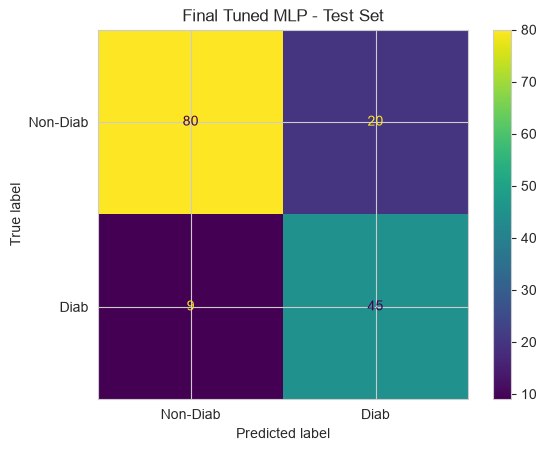

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       100
           1       0.69      0.83      0.76        54

    accuracy                           0.81       154
   macro avg       0.80      0.82      0.80       154
weighted avg       0.83      0.81      0.81       154



In [70]:
final_mlp = build_mlp(X_train_scaled.shape[1], units=best_cfg['units'],
                       dropout=best_cfg['dropout'], lr=best_cfg['lr'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
final_mlp.fit(X_train_scaled, y_train, validation_split=0.2, epochs=150,
              batch_size=int(best_cfg['batch_size']), callbacks=[es], verbose=0)

final_metrics, final_pred, final_prob = evaluate_model(
    'Final Tuned MLP', final_mlp, X_train_scaled, y_train, X_test_scaled, y_test, is_keras=True
)
print(final_metrics)

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Diab','Diab']).plot()
plt.title('Final Tuned MLP - Test Set'); plt.show()
print(classification_report(y_test, final_pred))

## 12. SAVE MODEL + PREPROCESSOR

In [71]:
final_mlp.save('diabetes_mlp.keras')
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

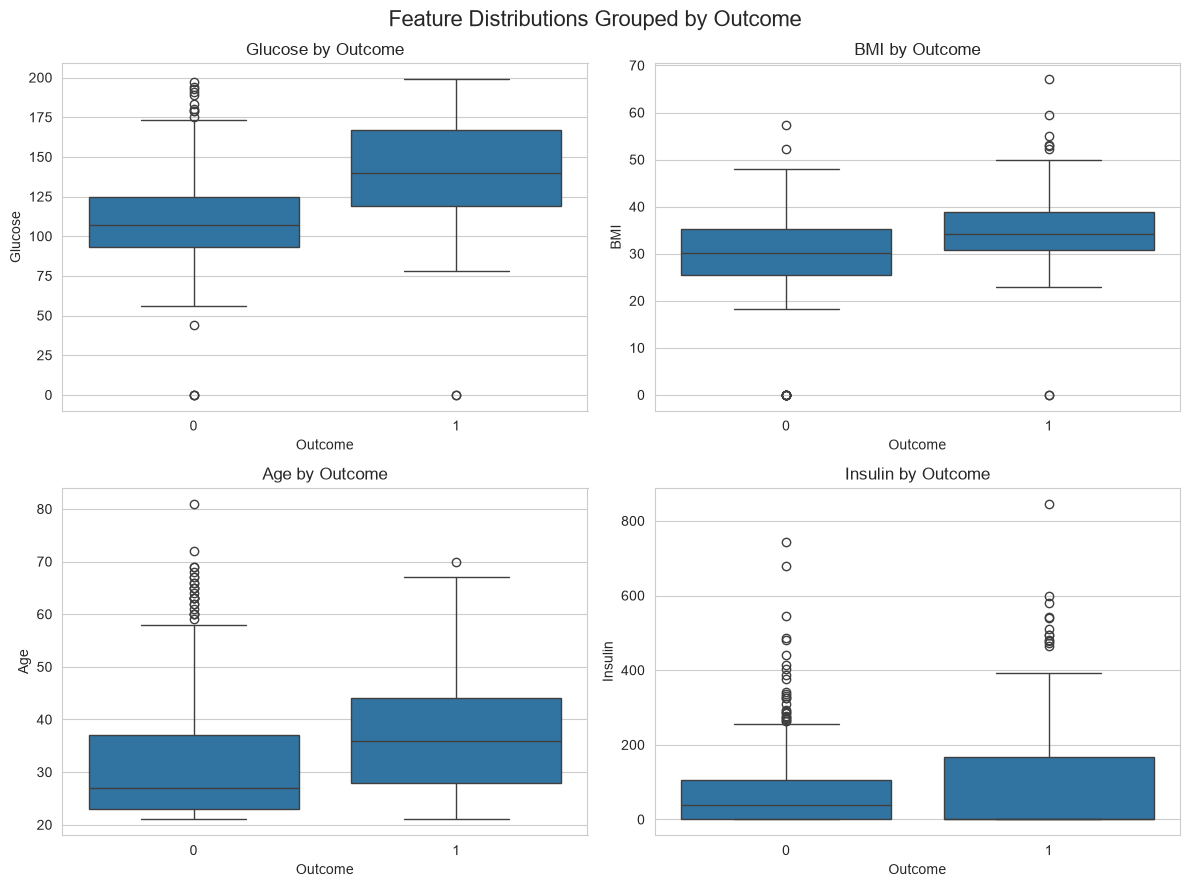

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to plot
features = [
    'Glucose',
    'BMI',
    'Age',
    'Insulin'
]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x='Outcome',
        y=feature,
        ax=ax
    )

    ax.set_title(f'{feature} by Outcome')
    ax.set_xlabel('Outcome')
    ax.set_ylabel(feature)

plt.suptitle('Feature Distributions Grouped by Outcome', fontsize=16)

plt.tight_layout()

# Save for LaTeX
plt.savefig(
    'figure/bivariate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

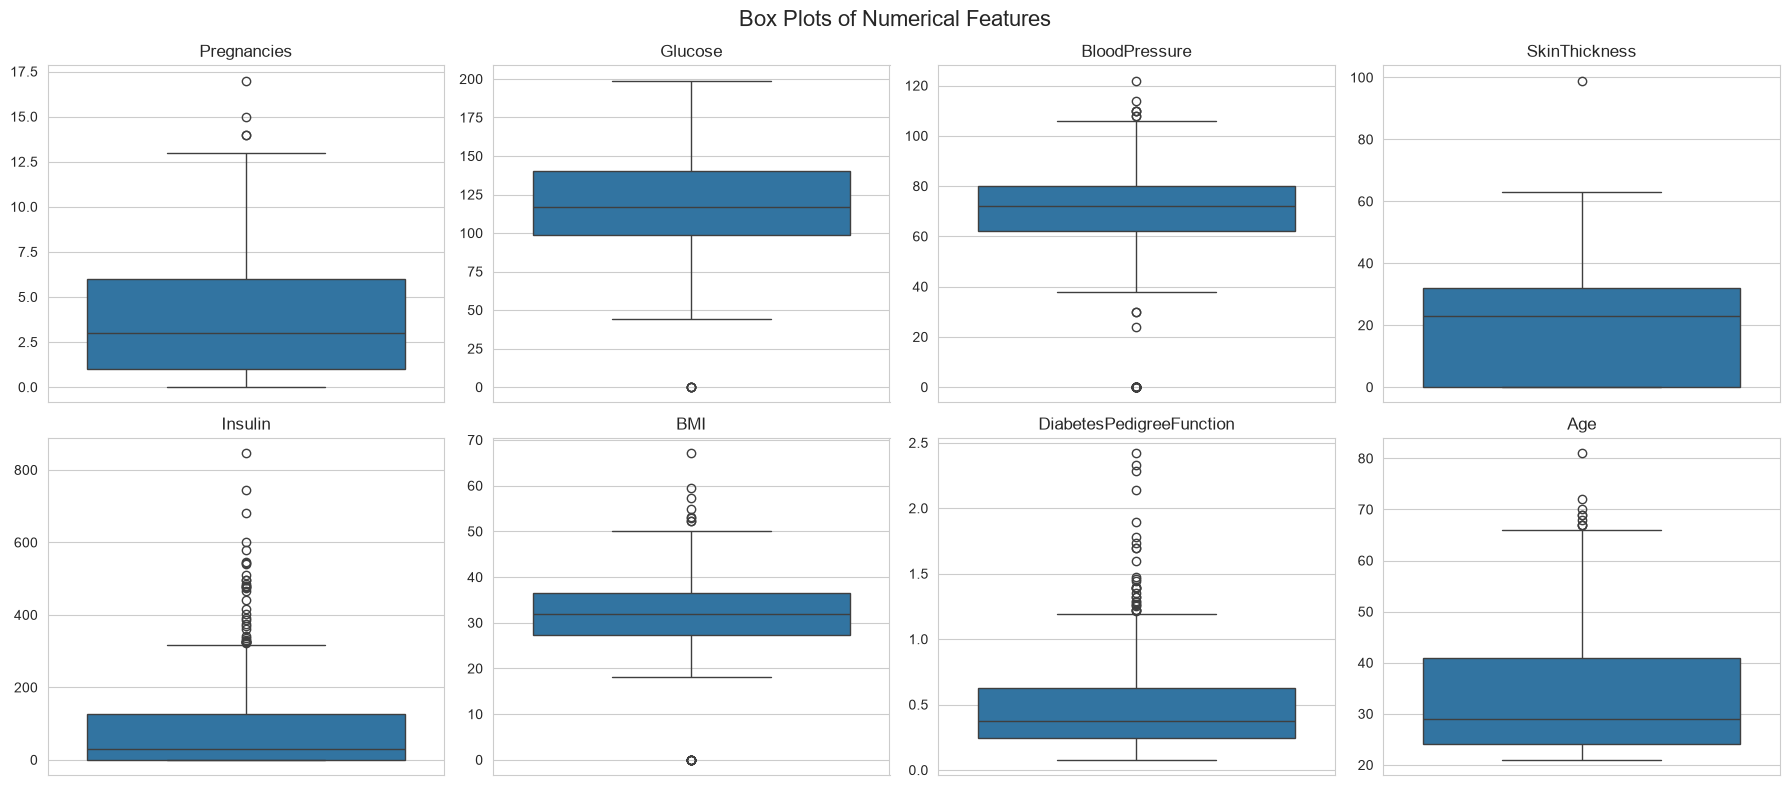

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Remove target column
num_cols = num_cols.drop('Outcome')

# Create boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Box Plots of Numerical Features', fontsize=16)

plt.tight_layout()

# Save for LaTeX
plt.savefig(
    'figure/boxplots.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

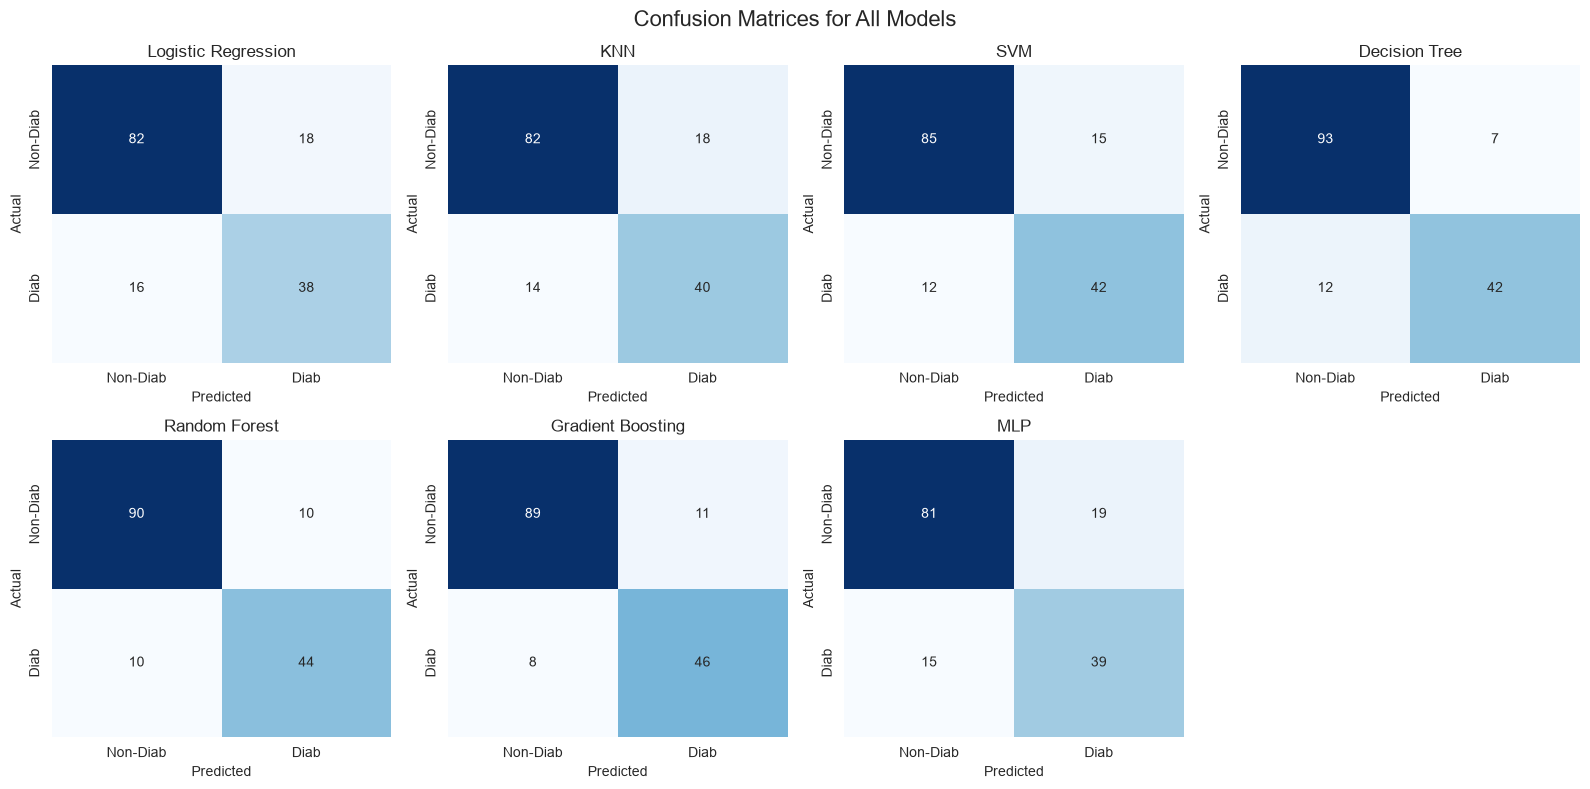

In [74]:
# %% [markdown]
# ## Confusion Matrices for All Models
# %%
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create 2 x 4 grid for all models
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (name, (y_pred, y_prob)) in zip(axes.flatten(), predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['Non-Diab', 'Diab'],
        yticklabels=['Non-Diab', 'Diab']
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide unused subplots
for ax in axes.flatten()[len(predictions):]:
    ax.axis('off')

plt.suptitle(
    'Confusion Matrices for All Models',
    fontsize=16
)

plt.tight_layout()

# Save for LaTeX
plt.savefig(
    'figure/confusion_matrices.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()